In [1]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("SCNE SQL and EDA") \
    .master("local[*]") \
    .getOrCreate()

DATA_PATH = r"D:\Big Data Programming Project\Final Assignment\data\processed\spark\scne_multiday_delay"

delay_df = spark.read.parquet(DATA_PATH)

delay_df.createOrReplaceTempView("delay_data")

print("Rows:", delay_df.count())
print("Columns:", len(delay_df.columns))
print("SQL view created: delay_data")

Rows: 308885
Columns: 35
SQL view created: delay_data


In [5]:
date_summary = spark.sql("""
SELECT
    service_date,
    COUNT(*) AS total_records,
    ROUND(AVG(delay_seconds), 2) AS average_delay_seconds,
    ROUND(MIN(delay_seconds), 2) AS minimum_delay_seconds,
    ROUND(MAX(delay_seconds), 2) AS maximum_delay_seconds
FROM delay_data
GROUP BY service_date
ORDER BY service_date
""")

date_summary.show()

+------------+-------------+---------------------+---------------------+---------------------+
|service_date|total_records|average_delay_seconds|minimum_delay_seconds|maximum_delay_seconds|
+------------+-------------+---------------------+---------------------+---------------------+
|  2025-12-26|        31891|                269.1|               -899.0|               1800.0|
|  2025-12-27|       170149|                60.21|               -899.0|               1800.0|
|  2025-12-28|       106845|               129.13|               -900.0|               1800.0|
+------------+-------------+---------------------+---------------------+---------------------+



In [6]:
route_summary = spark.sql("""
SELECT
    published_line_name AS route,
    COUNT(*) AS observations,
    ROUND(AVG(delay_seconds), 2) AS average_delay_seconds,
    ROUND(STDDEV(delay_seconds), 2) AS delay_stddev
FROM delay_data
GROUP BY published_line_name
HAVING COUNT(*) >= 100
ORDER BY average_delay_seconds DESC
LIMIT 20
""")

route_summary.show(20, truncate=False)

+-----+------------+---------------------+------------+
|route|observations|average_delay_seconds|delay_stddev|
+-----+------------+---------------------+------------+
|X78  |1332        |305.72               |486.75      |
|X63  |739         |295.56               |494.3       |
|E6   |4212        |205.83               |374.77      |
|23   |5736        |201.16               |310.78      |
|36   |10763       |184.62               |366.02      |
|58   |1642        |183.22               |409.97      |
|57   |502         |182.05               |397.1       |
|X47  |3763        |177.2                |385.58      |
|31   |7064        |166.18               |322.8       |
|X88  |2223        |165.82               |427.92      |
|4    |11799       |156.01               |300.79      |
|16   |7064        |154.72               |277.86      |
|30   |9065        |150.22               |278.32      |
|11   |14914       |149.44               |281.62      |
|X82  |1906        |145.96               |397.87

In [4]:
hour_summary = spark.sql("""
SELECT
    HOUR(scheduled_arrival_time) AS hour,
    COUNT(*) AS observations,
    ROUND(AVG(delay_seconds), 2) AS average_delay_seconds
FROM delay_data
GROUP BY HOUR(scheduled_arrival_time)
ORDER BY hour
""")

hour_summary.show(24)

+----+------------+---------------------+
|hour|observations|average_delay_seconds|
+----+------------+---------------------+
|   0|       15428|                90.05|
|   1|       12023|               122.98|
|   2|       11314|               113.15|
|   3|       11150|                 57.3|
|   4|       10971|                34.43|
|   5|        3410|                10.71|
|   8|          62|                -0.82|
|   9|         160|                59.16|
|  10|         357|                 3.69|
|  11|        1674|                65.68|
|  12|        5340|                 78.4|
|  13|       10025|                44.15|
|  14|       13826|                47.58|
|  15|       18962|                52.59|
|  16|       24302|                68.29|
|  17|       24919|               101.48|
|  18|       25234|               151.69|
|  19|       25172|                161.1|
|  20|       24877|               148.45|
|  21|       24435|               132.84|
|  22|       23417|               

In [5]:
delay_status = spark.sql("""
SELECT
    CASE
        WHEN delay_seconds < -60 THEN 'Early'
        WHEN delay_seconds <= 300 THEN 'On Time'
        ELSE 'Delayed'
    END AS delay_status,
    COUNT(*) AS observations,
    ROUND(
        COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (),
        2
    ) AS percentage
FROM delay_data
GROUP BY
    CASE
        WHEN delay_seconds < -60 THEN 'Early'
        WHEN delay_seconds <= 300 THEN 'On Time'
        ELSE 'Delayed'
    END
ORDER BY observations DESC
""")

delay_status.show()

+------------+------------+----------+
|delay_status|observations|percentage|
+------------+------------+----------+
|     On Time|      225820|     73.11|
|       Early|       44466|     14.40|
|     Delayed|       38599|     12.50|
+------------+------------+----------+



In [6]:
route_delay_stats = spark.sql("""
SELECT
    published_line_name AS route,
    COUNT(*) AS observations,
    ROUND(AVG(delay_seconds), 2) AS average_delay_seconds,
    ROUND(
        SUM(CASE WHEN delay_seconds > 300 THEN 1 ELSE 0 END)
        * 100.0 / COUNT(*),
        2
    ) AS delayed_percentage
FROM delay_data
GROUP BY published_line_name
HAVING COUNT(*) >= 100
ORDER BY observations DESC
LIMIT 20
""")

route_delay_stats.show(20, truncate=False)

+-----+------------+---------------------+------------------+
|route|observations|average_delay_seconds|delayed_percentage|
+-----+------------+---------------------+------------------+
|1    |21167       |43.77                |6.15              |
|12   |15487       |87.68                |11.02             |
|10   |15147       |127.12               |15.80             |
|11   |14914       |149.44               |18.51             |
|62   |13623       |66.25                |8.18              |
|22   |12650       |61.66                |8.17              |
|4    |11799       |156.01               |19.68             |
|63   |11538       |63.18                |9.32              |
|7    |10969       |67.01                |6.12              |
|40   |10917       |121.27               |13.84             |
|39   |10792       |99.11                |12.21             |
|36   |10763       |184.62               |20.75             |
|38   |10595       |98.26                |13.75             |
|13   |9

In [7]:
ranked_routes = spark.sql("""
WITH route_summary AS (
    SELECT
        published_line_name AS route,
        COUNT(*) AS observations,
        ROUND(AVG(delay_seconds), 2) AS average_delay_seconds
    FROM delay_data
    GROUP BY published_line_name
    HAVING COUNT(*) >= 100
)

SELECT
    route,
    observations,
    average_delay_seconds,
    DENSE_RANK() OVER (
        ORDER BY average_delay_seconds DESC
    ) AS delay_rank
FROM route_summary
ORDER BY delay_rank
LIMIT 20
""")

ranked_routes.show(20, truncate=False)

+-----+------------+---------------------+----------+
|route|observations|average_delay_seconds|delay_rank|
+-----+------------+---------------------+----------+
|X78  |1332        |305.72               |1         |
|X63  |739         |295.56               |2         |
|E6   |4212        |205.83               |3         |
|23   |5736        |201.16               |4         |
|36   |10763       |184.62               |5         |
|58   |1642        |183.22               |6         |
|57   |502         |182.05               |7         |
|X47  |3763        |177.2                |8         |
|31   |7064        |166.18               |9         |
|X88  |2223        |165.82               |10        |
|4    |11799       |156.01               |11        |
|16   |7064        |154.72               |12        |
|30   |9065        |150.22               |13        |
|11   |14914       |149.44               |14        |
|X82  |1906        |145.96               |15        |
|E2   |4439        |143.62  

In [8]:
stop_summary = spark.sql("""
SELECT
    stop_id,
    stop_name,
    COUNT(*) AS observations,
    ROUND(AVG(delay_seconds), 2) AS average_delay_seconds
FROM delay_data
GROUP BY stop_id, stop_name
HAVING COUNT(*) >= 100
ORDER BY average_delay_seconds DESC
LIMIT 20
""")

stop_summary.show(20, truncate=False)

+------------+-------------------------------+------------+---------------------+
|stop_id     |stop_name                      |observations|average_delay_seconds|
+------------+-------------------------------+------------+---------------------+
|410000017088|King George Road-Leisure Centre|113         |517.88               |
|410000008359|Windsor Way-Fawdon Walk        |113         |491.54               |
|410000017975|Stanhope Road-Boldon Lane      |156         |450.31               |
|410000017047|Boldon Lane - Harton Lane      |158         |449.28               |
|410000042C02|Stanhope Parade                |121         |440.3                |
|077072491B  |Stockton Rail Station          |107         |434.72               |
|410000017101|Stanhope Rd-Talbot Road        |103         |421.37               |
|410000008308|Blakelaw Road-Wilbury Place    |153         |403.95               |
|077072638A  |Currys                         |190         |381.72               |
|410000042143|Su

In [9]:
day_type_summary = spark.sql("""
SELECT
    CASE
        WHEN service_date = DATE('2025-12-26') THEN 'Public Holiday'
        ELSE 'Weekend'
    END AS day_type,
    COUNT(*) AS observations,
    ROUND(AVG(delay_seconds), 2) AS average_delay_seconds
FROM delay_data
GROUP BY
    CASE
        WHEN service_date = DATE('2025-12-26') THEN 'Public Holiday'
        ELSE 'Weekend'
    END
ORDER BY average_delay_seconds DESC
""")

day_type_summary.show()

+--------------+------------+---------------------+
|      day_type|observations|average_delay_seconds|
+--------------+------------+---------------------+
|Public Holiday|       31891|                269.1|
|       Weekend|      276994|                86.79|
+--------------+------------+---------------------+



In [10]:
rolling_delay = spark.sql("""
SELECT
    service_date,
    trip_id,
    stop_sequence,
    stop_name,
    delay_seconds,

    ROUND(
        AVG(delay_seconds) OVER (
            PARTITION BY service_date, trip_id
            ORDER BY stop_sequence
            ROWS BETWEEN 2 PRECEDING AND CURRENT ROW
        ),
        2
    ) AS rolling_3_stop_delay

FROM delay_data
ORDER BY service_date, trip_id, stop_sequence
""")

rolling_delay.show(20, truncate=False)

+------------+------------------------------------------+-------------+------------------------------+-------------+--------------------+
|service_date|trip_id                                   |stop_sequence|stop_name                     |delay_seconds|rolling_3_stop_delay|
+------------+------------------------------------------+-------------+------------------------------+-------------+--------------------+
|2025-12-26  |VJ00281d66b067d9e9e4b472236e1e40548cea038c|0            |Whickham View Terminus        |4.0          |4.0                 |
|2025-12-26  |VJ00281d66b067d9e9e4b472236e1e40548cea038c|2            |Whickham View-Muscott Grove   |-56.0        |-26.0               |
|2025-12-26  |VJ00281d66b067d9e9e4b472236e1e40548cea038c|4            |Ferguson's Lane-Brambles Dykes|-115.0       |-55.67              |
|2025-12-26  |VJ00281d66b067d9e9e4b472236e1e40548cea038c|6            |Benwell Village               |-135.0       |-102.0              |
|2025-12-26  |VJ00281d66b067d9e9e4

In [11]:
STOP_PATH = r"D:\Big Data Programming Project\Final Assignment\data\interim\timetable\2025-12-28\scne_active_stops.csv"

stops_df = spark.read \
    .option("header", True) \
    .option("inferSchema", True) \
    .csv(STOP_PATH)

stops_df.createOrReplaceTempView("gtfs_stops")

joined_stops = spark.sql("""
SELECT
    d.service_date,
    d.trip_id,
    d.published_line_name AS route,
    d.stop_id,
    s.stop_name,
    d.delay_seconds
FROM delay_data d
INNER JOIN gtfs_stops s
    ON d.stop_id = s.stop_id
WHERE d.service_date = DATE('2025-12-28')
""")

print("Joined rows:", joined_stops.count())
joined_stops.show(10, truncate=False)

Joined rows: 106845
+------------+------------------------------------------+-----+------------+--------------------------------+-------------+
|service_date|trip_id                                   |route|stop_id     |stop_name                       |delay_seconds|
+------------+------------------------------------------+-----+------------+--------------------------------+-------------+
|2025-12-28  |VJ346d439d74182a6c7c2a82815d8175bb45a30dcf|62   |410000008083|Ponteland Road-Fenham Hall Drive|68.0         |
|2025-12-28  |VJ04b040058d2cad7d70d071ef92f0edf0560d8e25|31   |410000014565|Adelaide Terrace                |133.0        |
|2025-12-28  |VJ2ce4db4c0b67342b5537d2066123c227a67b7cc8|22   |410000013514|Northumberland Road             |10.0         |
|2025-12-28  |VJ410d8fcb445080fcc491d69a6347b711a314fd9a|13   |410000042S04|Station Road-Industrial Estate  |33.0         |
|2025-12-28  |VJ1afd7fe875cc69ea6b7676aa677a00b1850b26bc|32A  |410000014614|Buddle Road                     |47.

In [12]:
from pyspark.sql import functions as F

dataframe_summary = (
    delay_df
    .groupBy("service_date")
    .agg(
        F.count("*").alias("total_records"),
        F.round(F.avg("delay_seconds"), 2).alias("average_delay_seconds")
    )
    .orderBy("service_date")
)

dataframe_summary.show()

+------------+-------------+---------------------+
|service_date|total_records|average_delay_seconds|
+------------+-------------+---------------------+
|  2025-12-26|        31891|                269.1|
|  2025-12-27|       170149|                60.21|
|  2025-12-28|       106845|               129.13|
+------------+-------------+---------------------+



In [7]:
from pyspark.sql import functions as F

profile = delay_df.agg(
    F.count("*").alias("total_records"),
    F.sum(F.when(F.col("delay_seconds").isNull(), 1).otherwise(0)).alias("null_delay"),
    F.sum(F.when(F.col("trip_id").isNull(), 1).otherwise(0)).alias("null_trip_id"),
    F.sum(F.when(F.col("published_line_name").isNull(), 1).otherwise(0)).alias("null_route"),
    F.sum(F.when(F.col("stop_id").isNull(), 1).otherwise(0)).alias("null_stop_id"),
    F.round(F.avg("delay_seconds"), 2).alias("mean_delay"),
    F.round(
        F.expr("percentile_approx(delay_seconds, 0.5)"),
        2
    ).alias("median_delay"),
    F.round(F.stddev("delay_seconds"), 2).alias("standard_deviation"),
    F.round(F.skewness("delay_seconds"), 2).alias("skewness"),
    F.round(F.kurtosis("delay_seconds"), 2).alias("kurtosis"),
    F.countDistinct("published_line_name").alias("unique_routes"),
    F.countDistinct("trip_id").alias("unique_trips"),
    F.countDistinct("stop_id").alias("unique_stops")
).first()

profile_output = [
    ("Total records", str(profile["total_records"])),
    ("Null delay values", str(profile["null_delay"])),
    ("Null trip IDs", str(profile["null_trip_id"])),
    ("Null route values", str(profile["null_route"])),
    ("Null stop IDs", str(profile["null_stop_id"])),
    ("Mean delay (seconds)", str(profile["mean_delay"])),
    ("Median delay (seconds)", str(profile["median_delay"])),
    ("Standard deviation", str(profile["standard_deviation"])),
    ("Skewness", str(profile["skewness"])),
    ("Kurtosis", str(profile["kurtosis"])),
    ("Unique routes", str(profile["unique_routes"])),
    ("Unique trips", str(profile["unique_trips"])),
    ("Unique stops", str(profile["unique_stops"]))
]

profile_df = spark.createDataFrame(
    profile_output,
    ["Metric", "Value"]
)

profile_df.show(20, truncate=False)

+----------------------+------+
|Metric                |Value |
+----------------------+------+
|Total records         |308885|
|Null delay values     |0     |
|Null trip IDs         |0     |
|Null route values     |0     |
|Null stop IDs         |0     |
|Mean delay (seconds)  |105.61|
|Median delay (seconds)|39.0  |
|Standard deviation    |257.51|
|Skewness              |2.56  |
|Kurtosis              |10.1  |
|Unique routes         |62    |
|Unique trips          |8526  |
|Unique stops          |4026  |
+----------------------+------+



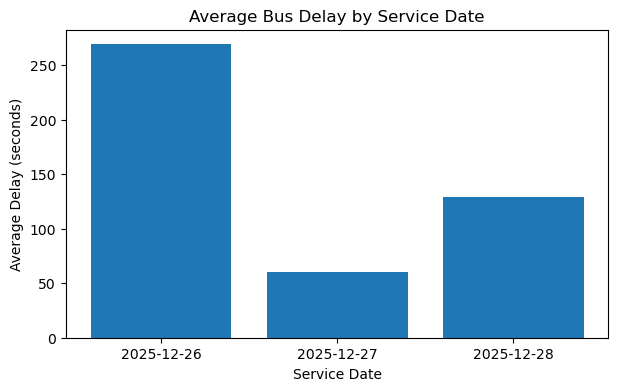

In [13]:
import matplotlib.pyplot as plt

plot_data = date_summary.toPandas()

plt.figure(figsize=(7, 4))
plt.bar(
    plot_data["service_date"].astype(str),
    plot_data["average_delay_seconds"]
)

plt.title("Average Bus Delay by Service Date")
plt.xlabel("Service Date")
plt.ylabel("Average Delay (seconds)")
plt.xticks(rotation=0)

plt.show()

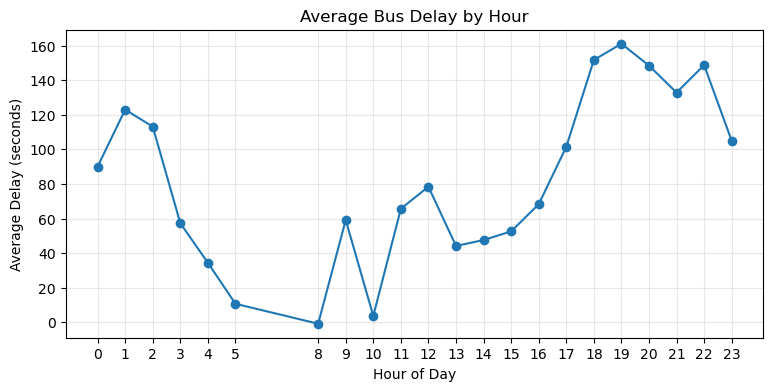

In [14]:
hour_plot = hour_summary.toPandas()

plt.figure(figsize=(9, 4))

plt.plot(
    hour_plot["hour"],
    hour_plot["average_delay_seconds"],
    marker="o"
)

plt.title("Average Bus Delay by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average Delay (seconds)")
plt.xticks(hour_plot["hour"])

plt.grid(True, alpha=0.3)

plt.show()

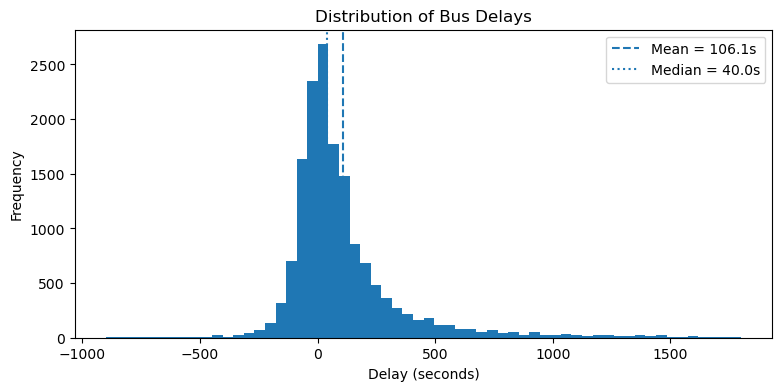

In [17]:
delay_sample = (
    delay_df
    .select("delay_seconds")
    .sample(False, 0.05, seed=42)
    .toPandas()
)

mean_delay = delay_sample["delay_seconds"].mean()
median_delay = delay_sample["delay_seconds"].median()

plt.figure(figsize=(9, 4))

plt.hist(
    delay_sample["delay_seconds"],
    bins=60
)

plt.axvline(mean_delay, linestyle="--", label=f"Mean = {mean_delay:.1f}s")
plt.axvline(median_delay, linestyle=":", label=f"Median = {median_delay:.1f}s")

plt.title("Distribution of Bus Delays")
plt.xlabel("Delay (seconds)")
plt.ylabel("Frequency")

plt.legend()
plt.show()

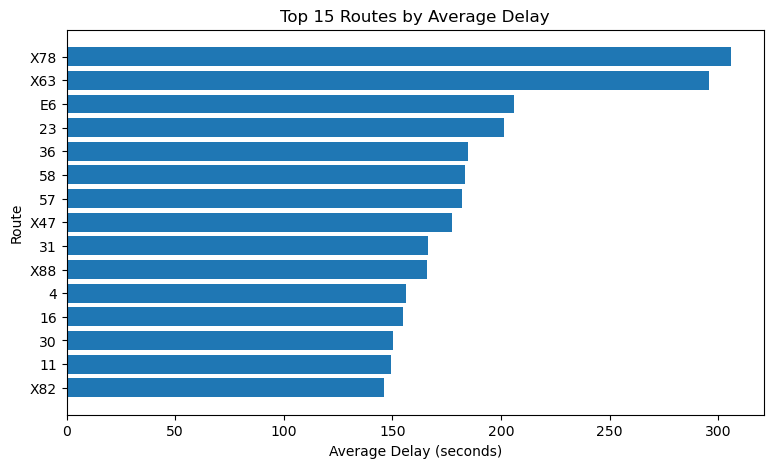

In [18]:
top_routes_plot = route_summary.limit(15).toPandas()

plt.figure(figsize=(9, 5))

plt.barh(
    top_routes_plot["route"][::-1],
    top_routes_plot["average_delay_seconds"][::-1]
)

plt.title("Top 15 Routes by Average Delay")
plt.xlabel("Average Delay (seconds)")
plt.ylabel("Route")

plt.show()

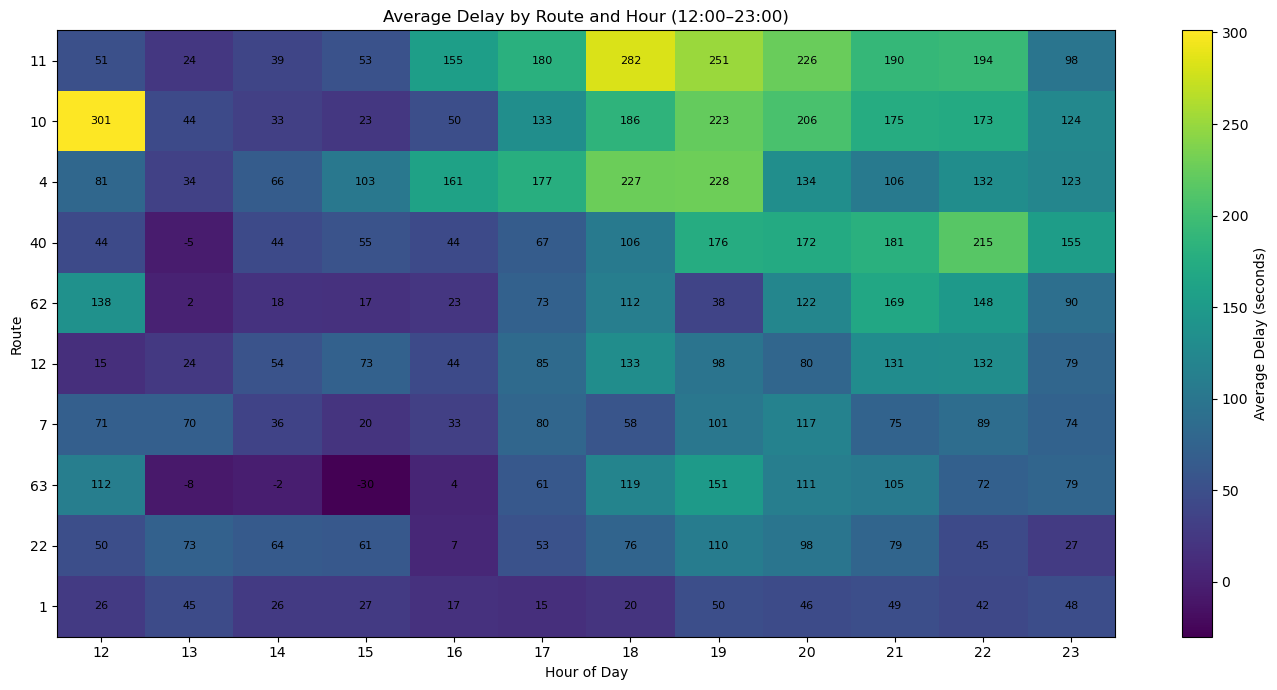

In [21]:
import numpy as np
import matplotlib.pyplot as plt

# Keep the busiest 10 routes
top_10_routes = (
    delay_df.groupBy("published_line_name")
    .count()
    .orderBy("count", ascending=False)
    .limit(10)
    .toPandas()["published_line_name"]
    .tolist()
)

# Focus on main operating hours
clear_heatmap = heatmap_data[
    (heatmap_data["route"].isin(top_10_routes)) &
    (heatmap_data["hour"].between(12, 23))
]

pivot_clear = clear_heatmap.pivot(
    index="route",
    columns="hour",
    values="average_delay"
)

# Sort routes by their overall average delay
route_order = (
    pivot_clear.mean(axis=1)
    .sort_values(ascending=False)
    .index
)

pivot_clear = pivot_clear.loc[route_order]

plt.figure(figsize=(14, 7))

masked = np.ma.masked_invalid(pivot_clear.values)

plt.imshow(masked, aspect="auto")

plt.colorbar(label="Average Delay (seconds)")

plt.xticks(
    range(len(pivot_clear.columns)),
    pivot_clear.columns
)

plt.yticks(
    range(len(pivot_clear.index)),
    pivot_clear.index
)

# Add values inside cells
for i in range(len(pivot_clear.index)):
    for j in range(len(pivot_clear.columns)):
        value = pivot_clear.iloc[i, j]

        if not np.isnan(value):
            plt.text(
                j,
                i,
                f"{value:.0f}",
                ha="center",
                va="center",
                fontsize=8
            )

plt.title("Average Delay by Route and Hour (12:00–23:00)")
plt.xlabel("Hour of Day")
plt.ylabel("Route")

plt.tight_layout()
plt.show()

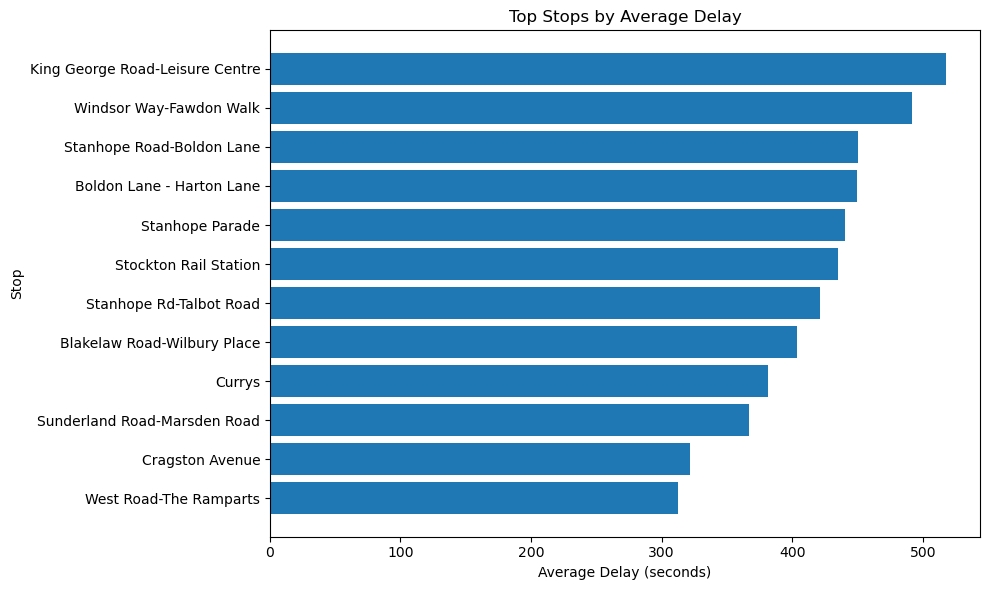

In [22]:
top_stops_plot = stop_summary.limit(12).toPandas()

plt.figure(figsize=(10, 6))

plt.barh(
    top_stops_plot["stop_name"][::-1],
    top_stops_plot["average_delay_seconds"][::-1]
)

plt.title("Top Stops by Average Delay")
plt.xlabel("Average Delay (seconds)")
plt.ylabel("Stop")

plt.tight_layout()
plt.show()

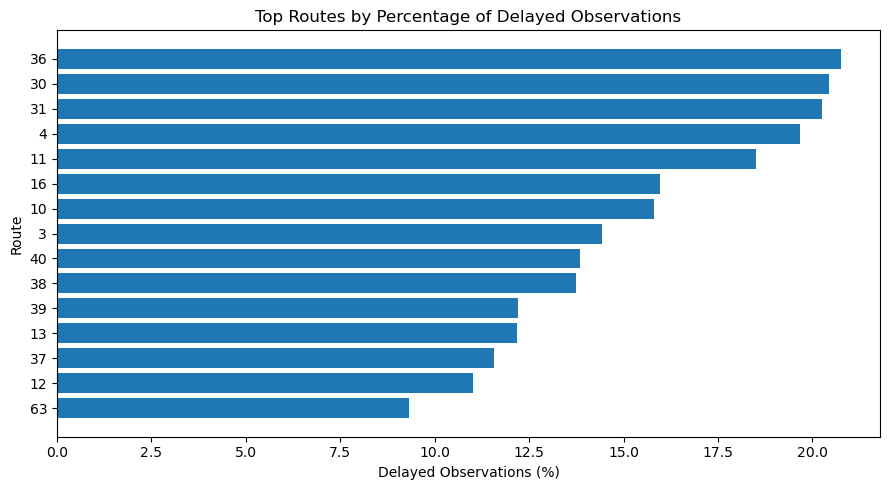

In [23]:
route_delay_plot = (
    route_delay_stats
    .orderBy("delayed_percentage", ascending=False)
    .limit(15)
    .toPandas()
)

plt.figure(figsize=(9, 5))

plt.barh(
    route_delay_plot["route"][::-1],
    route_delay_plot["delayed_percentage"][::-1]
)

plt.title("Top Routes by Percentage of Delayed Observations")
plt.xlabel("Delayed Observations (%)")
plt.ylabel("Route")

plt.tight_layout()
plt.show()

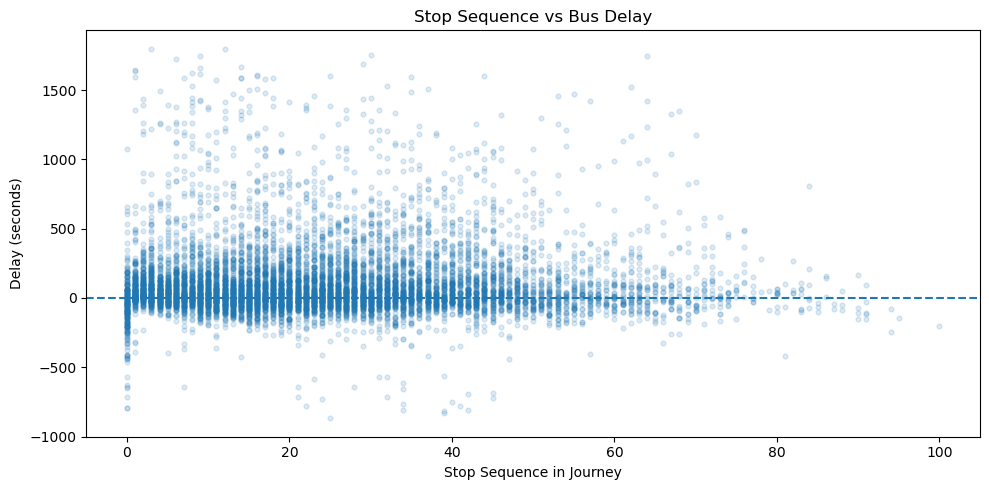

In [24]:
scatter_sample = (
    delay_df
    .select("stop_sequence", "delay_seconds")
    .sample(False, 0.03, seed=42)
    .toPandas()
)

plt.figure(figsize=(10, 5))

plt.scatter(
    scatter_sample["stop_sequence"],
    scatter_sample["delay_seconds"],
    alpha=0.15,
    s=12
)

plt.axhline(0, linestyle="--")

plt.title("Stop Sequence vs Bus Delay")
plt.xlabel("Stop Sequence in Journey")
plt.ylabel("Delay (seconds)")

plt.tight_layout()
plt.show()

In [25]:
correlation = delay_df.stat.corr(
    "stop_sequence",
    "delay_seconds"
)

print("Correlation between stop sequence and delay:")
print(round(correlation, 4))

Correlation between stop sequence and delay:
0.0111


<Figure size 900x500 with 0 Axes>

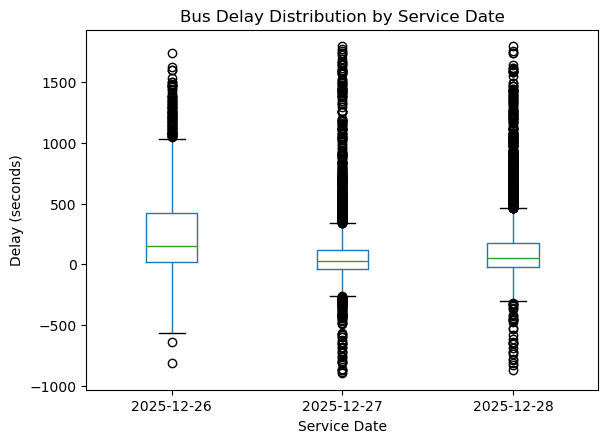

In [27]:
boxplot_sample = (
    delay_df
    .select("service_date", "delay_seconds")
    .sample(False, 0.05, seed=42)
    .toPandas()
)

plt.figure(figsize=(9, 5))

boxplot_sample.boxplot(
    column="delay_seconds",
    by="service_date",
    grid=False
)

plt.title("Bus Delay Distribution by Service Date")
plt.suptitle("")
plt.xlabel("Service Date")
plt.ylabel("Delay (seconds)")

plt.show()